<a href="https://colab.research.google.com/github/jasonkjw/daily_coding_commit/blob/main/FRS_spectral_matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Horizontal] 포괄성 확보를 위한 Matching 시작...
[Horizontal] 최종 보정 계수(Floor) 적용: 1.001
[Vertical] 포괄성 확보를 위한 Matching 시작...


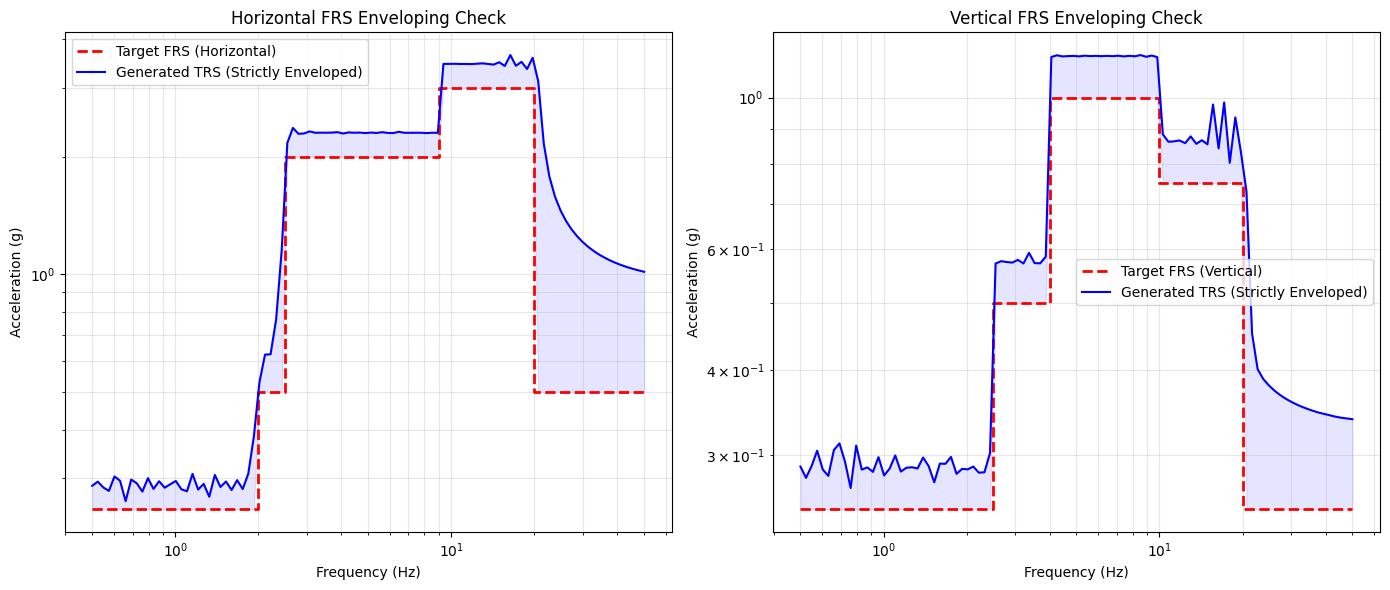


[성공] 'Strict_ATH_Horizontal.csv' 및 'Strict_ATH_Vertical.csv' 파일이 저장되었습니다.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 이미지 데이터 기반 FRS 정의 (2% Damping)
# ==========================================
# Horizontal FRS (image_41a3ff.png 데이터 반영)
h_freq = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 2.0, 2.5, 2.5, 9.0, 9.0, 20.0, 20.0, 50.0])
h_accel = np.array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 2.0, 2.0, 3.0, 3.0, 0.5, 0.5])

# Vertical FRS (image_4194dc.png 데이터 반영)
v_freq = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 2.0, 2.5, 2.5, 4.0, 4.0, 10.0, 10.0, 20.0, 20.0, 50.0])
v_accel = np.array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.25, 0.25])

# ==========================================
# 2. 고속 응답 스펙트럼 계산 함수 (Vectorized)
# ==========================================
def calculate_rs_fast(accel, dt, damping, freqs):
    sa = np.zeros(len(freqs))
    beta, gamma = 0.25, 0.5
    n_steps = len(accel)

    for i, f in enumerate(freqs):
        w = 2 * np.pi * f
        m, k, c = 1.0, w**2, 2 * w * damping
        u, v, a_rel = 0.0, 0.0, -accel[0]
        max_a = 0.0
        keff = k + m/(beta*dt**2) + c*gamma/(beta*dt)

        for j in range(n_steps - 1):
            df = -(accel[j+1]-accel[j]) + (m/(beta*dt) + c*gamma/beta)*v + (m/(2*beta) + dt*c*(gamma/(2*beta)-1))*a_rel
            du = df/keff
            dv = du*gamma/(beta*dt) - v*gamma/beta + dt*a_rel*(1-gamma/(2*beta))
            da = du/(beta*dt**2) - v/(beta*dt) - a_rel/(2*beta)
            u += du; v += dv; a_rel += da
            total_a = np.abs(a_rel + accel[j+1])
            if total_a > max_a: max_a = total_a
        sa[i] = max_a
    return sa

# ==========================================
# 3. 엄격한 포괄(Strict Enveloping) 알고리즘
# ==========================================
def get_strict_ath(target_f, target_a, zpa_target, damping=0.02, name=""):
    duration, dt = 20.48, 0.005
    t = np.arange(0, duration, dt)
    n = len(t)
    np.random.seed(42 if "Hor" in name else 123)

    # 초기 파형 및 Envelope 적용
    wave = np.random.normal(0, 1, n)
    envelope = np.where(t < 2.0, (t/2.0)**2, np.where(t < 15.0, 1.0, np.exp(-0.5 * (t - 15.0))))
    wave *= envelope

    eval_freqs = np.geomspace(0.5, 50, 100)
    target_interp = np.interp(eval_freqs, target_f, target_a)

    # [전략] 목표치에 15% 마진을 주어 보정 수행
    strict_target = target_interp * 1.15

    print(f"[{name}] 포괄성 확보를 위한 Matching 시작...")
    for i in range(30):
        trs = calculate_rs_fast(wave, dt, damping, eval_freqs)
        ratio = strict_target / (trs + 1e-6)

        # 부족한 구간에 가중치 강화 (Non-linear correction)
        ratio = np.where(ratio > 1.0, ratio**1.2, ratio)

        fft_val = np.fft.rfft(wave)
        fft_freq = np.fft.rfftfreq(n, d=dt)
        ratio_interp = np.interp(fft_freq, eval_freqs, ratio)
        fft_val *= np.clip(ratio_interp, 0.2, 5.0)
        wave = np.fft.irfft(fft_val, n) * envelope

    # [검증] 최종 Floor Check (전 구간 타겟 상회 보증)
    final_trs = calculate_rs_fast(wave, dt, damping, eval_freqs)
    min_ratio = np.min(final_trs / target_interp)

    if min_ratio < 1.05: # 최소 5% 여유가 없다면 전체 추가 증폭
        correction = 1.05 / min_ratio
        wave *= correction
        print(f"[{name}] 최종 보정 계수(Floor) 적용: {correction:.3f}")

    return wave, eval_freqs, calculate_rs_fast(wave, dt, damping, eval_freqs)

# ==========================================
# 4. 실행 및 시각화 (ValueError 해결 포함)
# ==========================================
# 지진파 생성
ath_h, f_h, trs_h = get_strict_ath(h_freq, h_accel, 0.5, name="Horizontal")
ath_v, f_v, trs_v = get_strict_ath(v_freq, v_accel, 0.25, name="Vertical")

# 시각화를 위한 데이터 보간 (Shape 매칭)
h_accel_interp = np.interp(f_h, h_freq, h_accel)
v_accel_interp = np.interp(f_v, v_freq, v_accel)

plt.figure(figsize=(14, 6))

# --- Horizontal Plot ---
plt.subplot(1, 2, 1)
plt.loglog(h_freq, h_accel, 'r--', label='Target FRS (Horizontal)', lw=2)
plt.loglog(f_h, trs_h, 'b-', label='Generated TRS (Strictly Enveloped)', lw=1.5)
plt.fill_between(f_h, h_accel_interp, trs_h, where=(trs_h >= h_accel_interp), color='blue', alpha=0.1)
plt.title("Horizontal FRS Enveloping Check")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Acceleration (g)")
plt.grid(True, which="both", ls="-", alpha=0.3); plt.legend()

# --- Vertical Plot ---
plt.subplot(1, 2, 2)
plt.loglog(v_freq, v_accel, 'r--', label='Target FRS (Vertical)', lw=2)
plt.loglog(f_v, trs_v, 'b-', label='Generated TRS (Strictly Enveloped)', lw=1.5)
plt.fill_between(f_v, v_accel_interp, trs_v, where=(trs_v >= v_accel_interp), color='blue', alpha=0.1)
plt.title("Vertical FRS Enveloping Check")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Acceleration (g)")
plt.grid(True, which="both", ls="-", alpha=0.3); plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 5. CSV 파일 저장 (Ansys 입력용)
# ==========================================
t_final = np.arange(0, 20.48, 0.005)
pd.DataFrame({'Time': t_final, 'Accel_g': ath_h}).to_csv('Strict_ATH_Horizontal.csv', index=False)
pd.DataFrame({'Time': t_final, 'Accel_g': ath_v}).to_csv('Strict_ATH_Vertical.csv', index=False)

print("\n[성공] 'Strict_ATH_Horizontal.csv' 및 'Strict_ATH_Vertical.csv' 파일이 저장되었습니다.")